# Import Necessary Libraries

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Load the Dataset

In [9]:
data = pd.read_csv("C:/Users/Admin/Downloads/bank.csv")

# Analyze the dataset

In [11]:
data.shape

(11162, 17)

In [12]:
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [13]:
data.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no
11161,34,technician,married,secondary,no,0,no,no,cellular,9,jul,628,1,-1,0,unknown,no


In [14]:
data

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


In [15]:
data.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [16]:
print(data.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')


In [17]:
data.nunique()

age            76
job            12
marital         3
education       4
default         2
balance      3805
housing         2
loan            2
contact         3
day            31
month          12
duration     1428
campaign       36
pdays         472
previous       34
poutcome        4
deposit         2
dtype: int64

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [19]:
for i, col in enumerate(data.columns):
  print(data.columns[i], '::\n', data[str(col)].unique(), '\n\n')

age ::
 [59 56 41 55 54 42 60 37 28 38 30 29 46 31 35 32 49 43 26 40 33 23 48 45
 36 52 53 39 57 51 44 24 50 27 34 47 25 58 61 68 75 22 69 66 85 72 90 67
 71 21 74 65 62 83 70 76 77 19 73 63 20 78 95 64 79 82 18 86 84 87 92 81
 80 93 88 89] 


job ::
 ['admin.' 'technician' 'services' 'management' 'retired' 'blue-collar'
 'unemployed' 'entrepreneur' 'housemaid' 'unknown' 'self-employed'
 'student'] 


marital ::
 ['married' 'single' 'divorced'] 


education ::
 ['secondary' 'tertiary' 'primary' 'unknown'] 


default ::
 ['no' 'yes'] 


balance ::
 [2343   45 1270 ... 1594 2593 -134] 


housing ::
 ['yes' 'no'] 


loan ::
 ['no' 'yes'] 


contact ::
 ['unknown' 'cellular' 'telephone'] 


day ::
 [ 5  6  7  8  9 12 13 14 15 16 19 20 21 23 26 27 28 29 30  2  3  4 11 17
 18 24  1 10 22 25 31] 


month ::
 ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep'] 


duration ::
 [1042 1467 1389 ... 1504  818 1812] 


campaign ::
 [ 1  2  3  4  6  5  8 11  9 10 15 12 14  7 24

In [20]:
for column in data.select_dtypes(include=['object', 'category']).columns:
    print(f"Value counts for column: {column}")
    print(data[column].value_counts())

Value counts for column: job
job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64
Value counts for column: marital
marital
married     6351
single      3518
divorced    1293
Name: count, dtype: int64
Value counts for column: education
education
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: count, dtype: int64
Value counts for column: default
default
no     10994
yes      168
Name: count, dtype: int64
Value counts for column: housing
housing
no     5881
yes    5281
Name: count, dtype: int64
Value counts for column: loan
loan
no     9702
yes    1460
Name: count, dtype: int64
Value counts for column: contact
contact
cellular     8042
unknown      2346
telephone     774
Name: count, dtype: int64
Value counts for column: m

# Duplicates

In [22]:
data.duplicated().sum()

0

# Null Values

In [24]:
data.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

# outliers

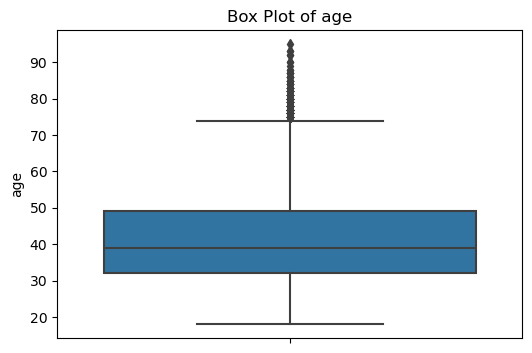

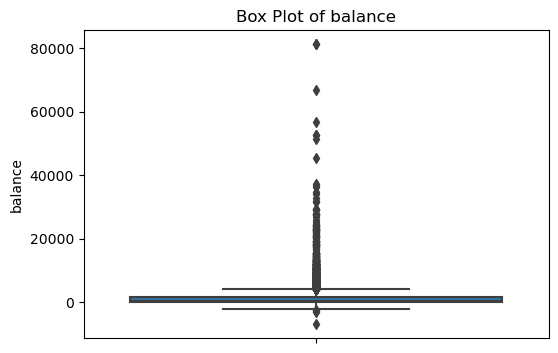

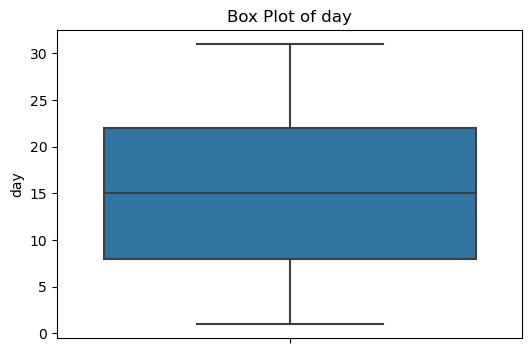

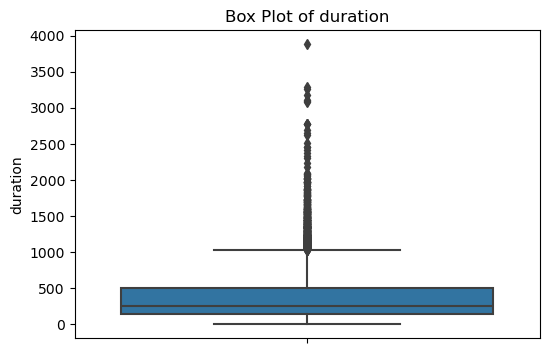

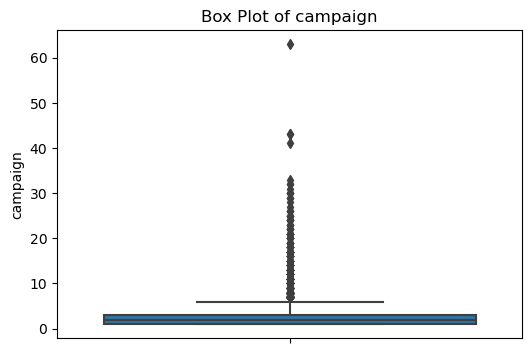

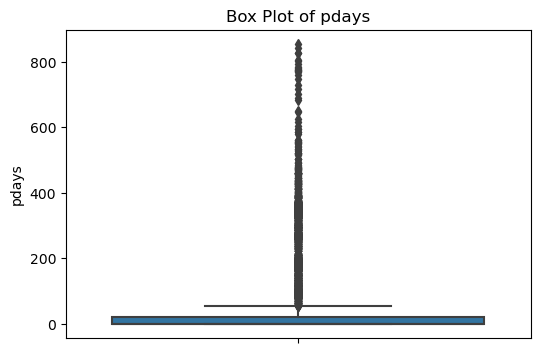

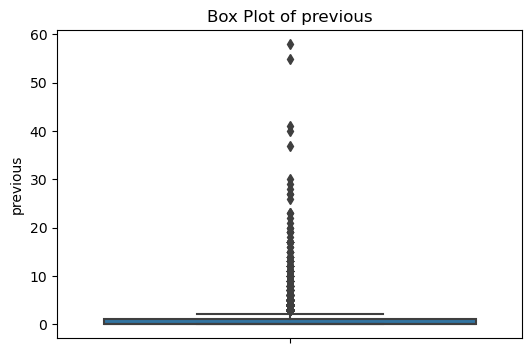

In [26]:
numeric_columns = data.select_dtypes(include=[np.number]).columns
for column in numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=data[column])
    plt.title(f'Box Plot of {column}')
    plt.show()

In [27]:
# Identify numerical columns
numerical_cols = data.select_dtypes(include=[np.number])
# Remove outliers based on IQR
for col in numerical_cols.columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]
data.shape

(6498, 17)

# Visualization

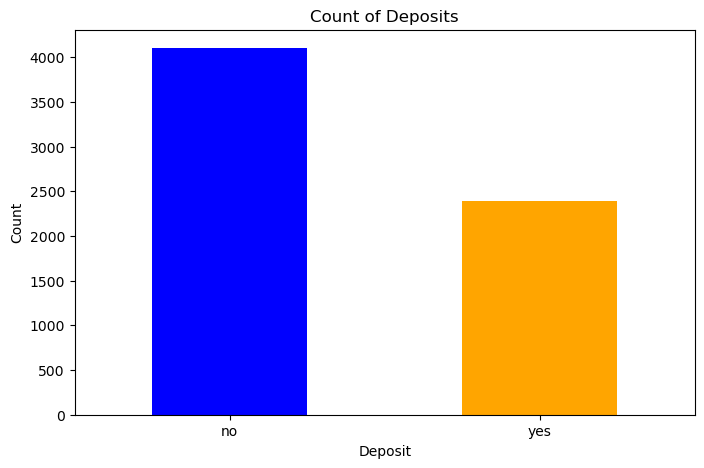

In [29]:
# Count occurrences of each category in the 'deposit' column
deposit_counts = data['deposit'].value_counts()
# Plotting the bar graph
plt.figure(figsize=(8, 5))
deposit_counts.plot(kind='bar', color=['blue', 'orange'])
plt.title('Count of Deposits')
plt.xlabel('Deposit')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

<Axes: xlabel='education', ylabel='balance'>

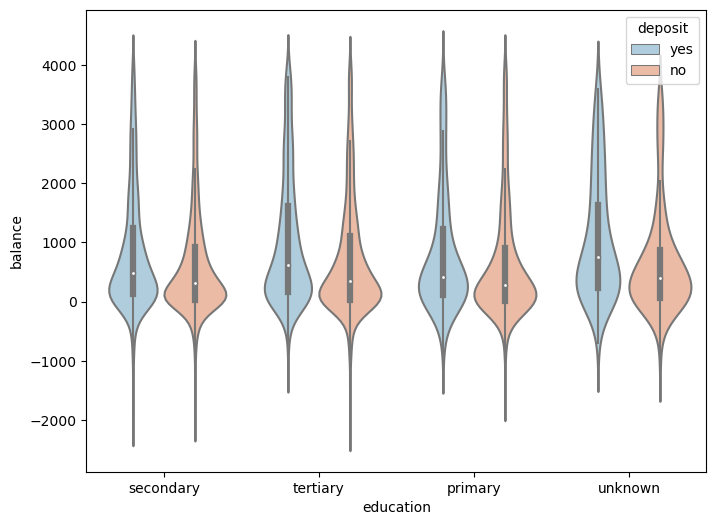

In [30]:
plt.figure(figsize=(8, 6)) 
sns.violinplot(data=data, x="education", y="balance", hue="deposit", palette="RdBu_r")

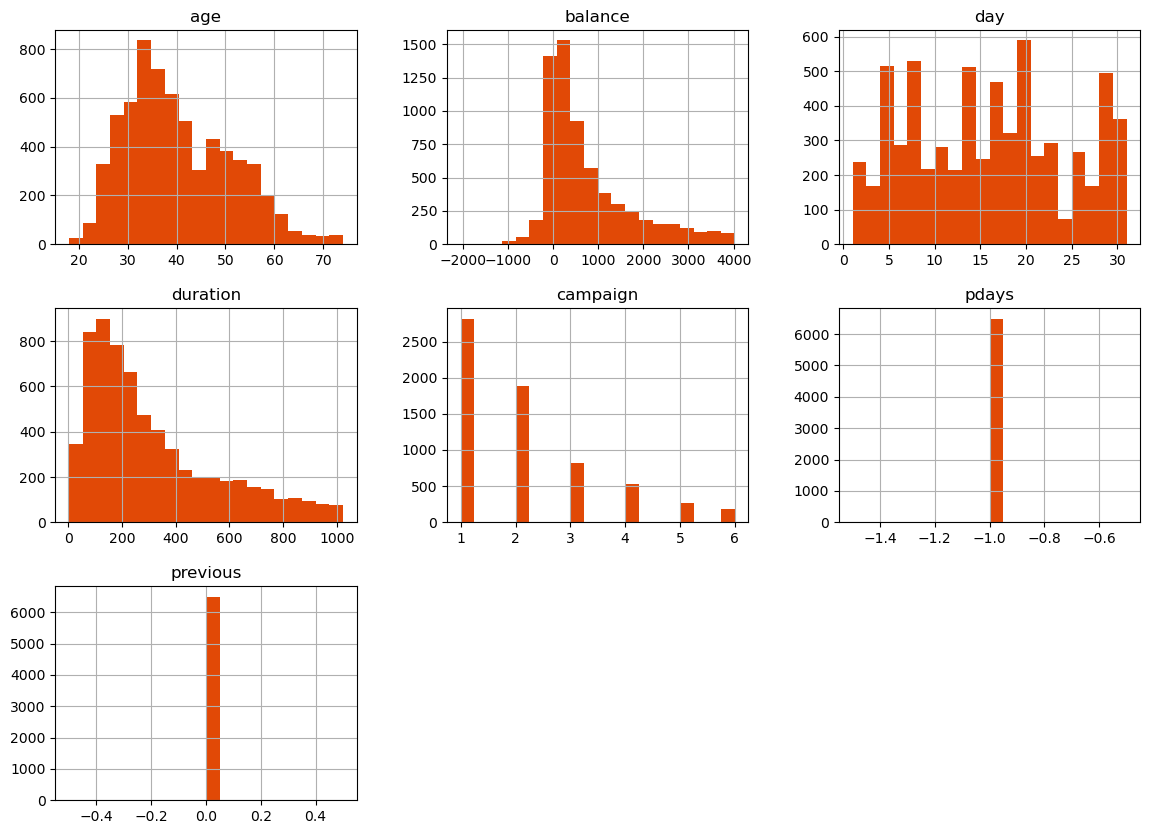

In [31]:
data.hist(bins=20, figsize=(14,10), color='#E14906')
plt.show()

# Split The Dataset

In [33]:
X = data.drop('deposit', axis=1)
y= data.deposit.to_frame()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)

(5523, 16) (5523, 1)
(975, 16) (975, 1)


# Apply Encoding for y_train and y_test

In [35]:
label_encoder = preprocessing.LabelEncoder()
for i in y_train.select_dtypes (include="object").columns:
     #if i not in exclude_columns:
     y_train[i]= label_encoder.fit_transform(y_train[i])

In [36]:
label_encoder = preprocessing.LabelEncoder()
for i in y_test.select_dtypes (include="object").columns:
     #if i not in exclude_columns:
     y_test[i]= label_encoder.fit_transform(y_test[i])

# Apply scaling and encoding for x_train and x_test

In [38]:
X_train_cat = X_train.select_dtypes(include=['object'])

In [39]:
X_train_num = X_train.select_dtypes(include=['int64','float64'])

In [40]:
X_test_cat = X_test.select_dtypes(include=['object'])

In [41]:
X_test_num = X_test.select_dtypes(include=['int64','float64'])

In [42]:
scaler = StandardScaler()
X_train_num_rescaled = pd.DataFrame(scaler.fit_transform(X_train_num),
                                   columns=X_train_num.columns,
                                   index=X_train_num.index)
X_test_num_rescaled = pd.DataFrame(scaler.transform(X_test_num),
                                   columns=X_test_num.columns,
                                   index=X_test_num.index)
X_train_num_rescaled.head()
X_test_num_rescaled.head()

,age,balance,day,duration,campaign,pdays,previous
9847,-1.586976,-0.679592,-1.392551,-0.093282,1.454402,0.0,0.0
3475,-0.011144,-0.689987,1.692416,0.628645,-0.841738,0.0,0.0
10246,0.915816,0.122850,0.031280,-0.470841,-0.841738,0.0,0.0
3726,2.584344,1.801534,-0.087373,0.997906,-0.076358,0.0,0.0
10041,-0.289232,-0.590201,0.149932,-0.188709,-0.076358,0.0,0.0


In [43]:
X_train_encoded = pd.get_dummies(X_train_cat, columns=X_train_cat.columns, drop_first=True)
X_test_encoded = pd.get_dummies(X_test_cat, columns=X_test_cat.columns, drop_first=True)
print(X_train_encoded.head())
print(X_test_encoded.head())

      job_blue-collar  job_entrepreneur  job_housemaid  job_management  \
946              True             False          False           False   
4728            False             False          False           False   
9651            False             False          False           False   
7658             True             False          False           False   
7277            False             False          False            True   

      job_retired  job_self-employed  job_services  job_student  \
946         False              False         False        False   
4728        False              False         False        False   
9651        False              False          True        False   
7658        False              False         False        False   
7277        False              False         False        False   

      job_technician  job_unemployed  ...  month_dec  month_feb  month_jan  \
946            False           False  ...      False      False      False

In [44]:
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

In [45]:
X_train_transformed = pd.concat([X_train_num_rescaled, X_train_encoded], axis=1)
X_test_transformed = pd.concat([X_test_num_rescaled, X_test_encoded], axis=1)

In [46]:
# Apply SMOTE to the training data
sm = SMOTE(random_state=0)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train_transformed, y_train)
# Check the class distribution after SMOTE
print("Original training set shape:", y_train.value_counts())
#print("Resampled training set shape:", pd.Series(y_train_resampled).value_counts())

Original training set shape: deposit
0          3491
1          2032
Name: count, dtype: int64


# Modelling

In [48]:
# Initialize and train the Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_resampled, y_train_resampled)
# Make predictions on the test set
y_pred_logistic = logistic_model.predict(X_test_transformed)
# Evaluate the model
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
# Print the results
print("Logistic Regression Accuracy:", accuracy_logistic)
print("\nClassification Report for Logistic Regression:\n", classification_report(y_test, y_pred_logistic))

Logistic Regression Accuracy: 0.8246153846153846

Classification Report for Logistic Regression:
               precision    recall  f1-score   support

           0       0.89      0.82      0.85       612
           1       0.73      0.83      0.78       363

    accuracy                           0.82       975
   macro avg       0.81      0.83      0.82       975
weighted avg       0.83      0.82      0.83       975



In [49]:
# Initialize and train the Decision Tree model
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train_resampled, y_train_resampled)
# Make predictions on the test set
y_pred_tree = decision_tree_model.predict(X_test_transformed)
# Evaluate the model
accuracy_tree = accuracy_score(y_test, y_pred_tree)
# Print the results
print("Decision Tree Accuracy:", accuracy_tree)
print("\nClassification Report for Decision Tree:\n", classification_report(y_test, y_pred_tree))

Decision Tree Accuracy: 0.7651282051282051

Classification Report for Decision Tree:
               precision    recall  f1-score   support

           0       0.84      0.77      0.81       612
           1       0.66      0.75      0.70       363

    accuracy                           0.77       975
   macro avg       0.75      0.76      0.75       975
weighted avg       0.77      0.77      0.77       975



In [50]:
# Initialize and train the Random Forest model
random_forest_model = RandomForestClassifier(random_state=42)
random_forest_model.fit(X_train_resampled, y_train_resampled)
# Make predictions on the test set
y_pred_forest = random_forest_model.predict(X_test_transformed)
# Evaluate the model
accuracy_forest = accuracy_score(y_test, y_pred_forest)
# Print the results
print("Random Forest Accuracy:", accuracy_forest)
print("\nClassification Report for Random Forest:\n", classification_report(y_test, y_pred_forest))

Random Forest Accuracy: 0.8574358974358974

Classification Report for Random Forest:
               precision    recall  f1-score   support

           0       0.93      0.83      0.88       612
           1       0.76      0.90      0.82       363

    accuracy                           0.86       975
   macro avg       0.85      0.87      0.85       975
weighted avg       0.87      0.86      0.86       975



In [51]:
# Initialize and train the Support Vector Machine model
svm_model = SVC(random_state=42)
svm_model.fit(X_train_resampled, y_train_resampled)
# Make predictions on the test set
y_pred_svm = svm_model.predict(X_test_transformed)
# Evaluate the model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
# Print the results
print("SVM Accuracy:", accuracy_svm)
print("\nClassification Report for SVM:\n", classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.8430769230769231

Classification Report for SVM:
               precision    recall  f1-score   support

           0       0.93      0.82      0.87       612
           1       0.74      0.89      0.81       363

    accuracy                           0.84       975
   macro avg       0.83      0.85      0.84       975
weighted avg       0.86      0.84      0.85       975



In [52]:
# Initialize and train the Naive Bayes model
naive_bayes_model = GaussianNB()
naive_bayes_model.fit(X_train_resampled, y_train_resampled)
# Make predictions on the test set
y_pred_nb = naive_bayes_model.predict(X_test_transformed)
# Evaluate the model
accuracy_nb = accuracy_score(y_test, y_pred_nb)
# Print the results
print("Naive Bayes Accuracy:", accuracy_nb)
print("\nClassification Report for Naive Bayes:\n", classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.7271794871794872

Classification Report for Naive Bayes:
               precision    recall  f1-score   support

           0       0.72      0.93      0.81       612
           1       0.77      0.38      0.51       363

    accuracy                           0.73       975
   macro avg       0.74      0.66      0.66       975
weighted avg       0.74      0.73      0.70       975



In [53]:
# Initialize and train the K-Nearest Neighbors model
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_resampled, y_train_resampled)  # Use ravel() to flatten y if necessary
# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test_transformed)
# Evaluate the model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
# Print the results
print("KNN Accuracy:", accuracy_knn)
print("\nClassification Report for KNN:\n", classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.8184615384615385

Classification Report for KNN:
               precision    recall  f1-score   support

           0       0.88      0.83      0.85       612
           1       0.73      0.80      0.77       363

    accuracy                           0.82       975
   macro avg       0.81      0.82      0.81       975
weighted avg       0.82      0.82      0.82       975



# Random Forest has best Accuracy